In [3]:
# Prerequisites
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import sys
from pathlib import Path

### 1. Load preprocessed model data
When you change the model and variable, you can see different result automatically!

In [4]:
MODEL = "GFDL-ESM4"
VARIABLE = "cVeg"

In [5]:
ds = xr.open_dataset(f"processed_data/TOAD_{VARIABLE}_{MODEL}.nc")

#### check resolution of model output

In [6]:
# spatial resolution
nominal_res = ds.attrs.get("nominal_resolution", "Not Available")
print(f"Nominal Resolution: {nominal_res}")

Nominal Resolution: 100 km


Annual average, with GWL dataset : `Variable you chose` : (GWL, lat, lon)

this data have annual average of variable in each grid in Amazon area.

In [7]:
print(ds)

<xarray.Dataset> Size: 579kB
Dimensions:  (lat: 30, GWL: 150, lon: 32)
Coordinates:
  * lat      (lat) float64 240B -19.5 -18.5 -17.5 -16.5 ... 6.5 7.5 8.5 9.5
    time     (GWL) object 1kB ...
  * lon      (lon) float64 256B 280.6 281.9 283.1 284.4 ... 316.9 318.1 319.4
    height   float64 8B ...
  * GWL      (GWL) float64 1kB -0.008147 -0.00433 -0.002064 ... 4.186 4.218
Data variables:
    cVeg     (GWL, lat, lon) float32 576kB ...
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               Amon
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/4d62897b-9155-43f5-b3b7-070d76059276
    variable_id:            tas
    variant_info:           N/A
    references:             see 

#### Plot and check data

##### (1) Average Trend of Variable in all amazon area

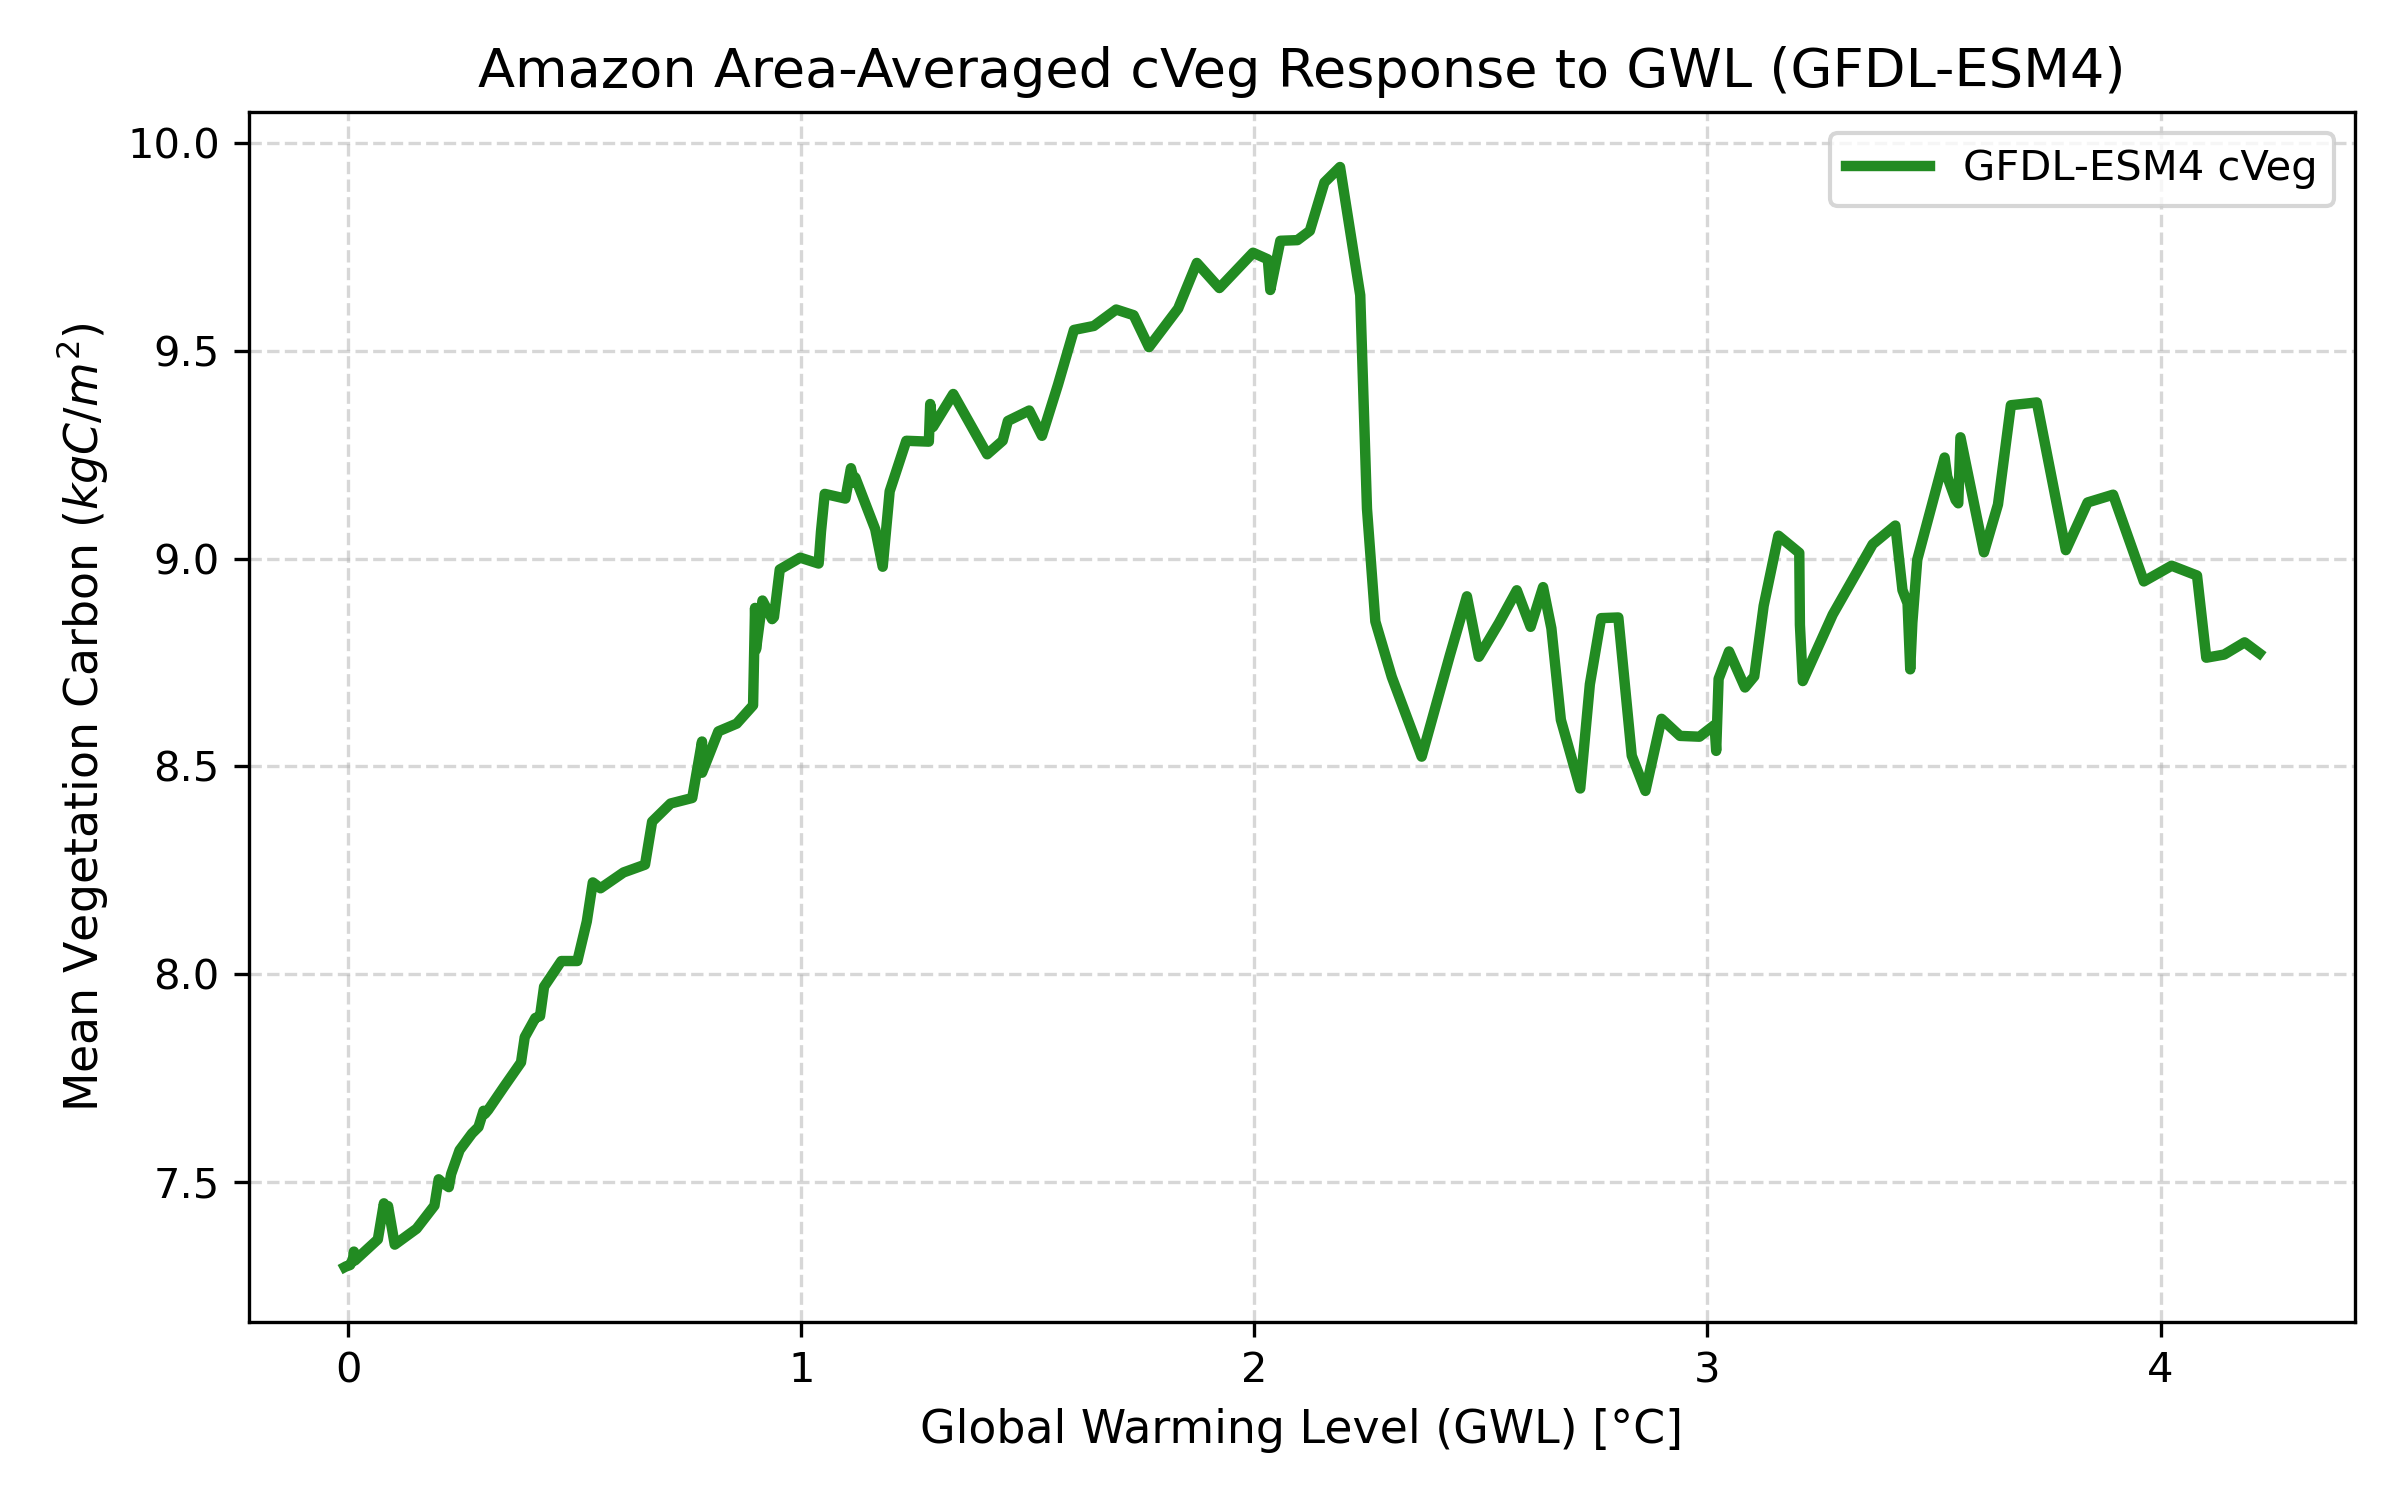

In [8]:
from IPython.display import Image, display

# image path
img_path = f"./plots/Trendplot_{VARIABLE}_{MODEL}.png"

# show image
display(Image(filename=img_path))

##### (2) Spatial Distribution by different Global Warming Level

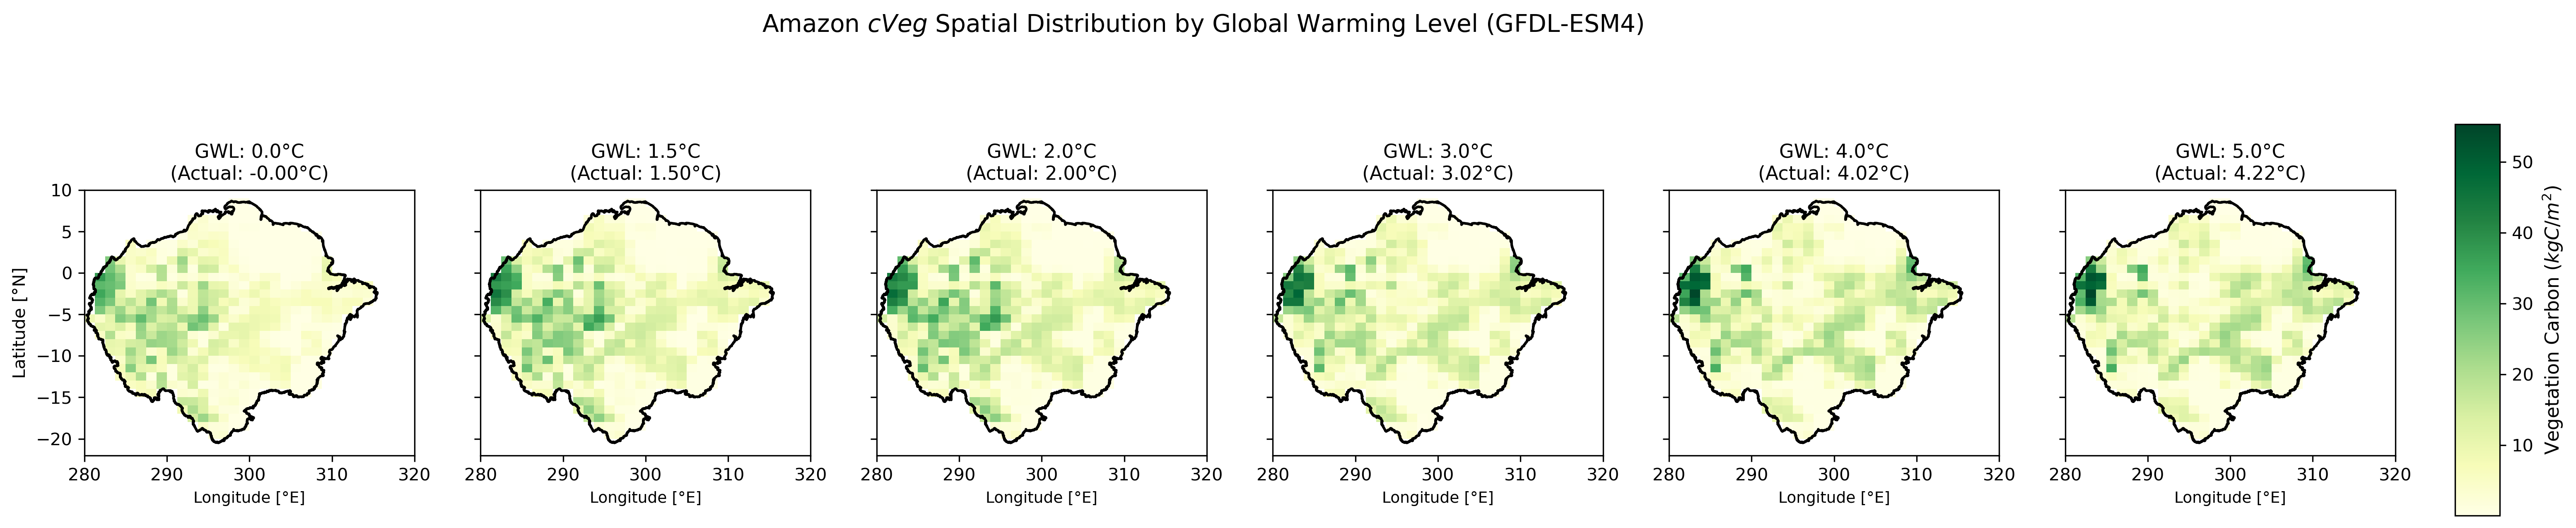

In [9]:
# image path
img_path = f"./plots/SpatialMap_{VARIABLE}_{MODEL}.png"

# show image
display(Image(filename=img_path))

### Start TOAD

In [10]:
import sys
import os

# Get the parent directory of the 'test' folder
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Target the 'toad-main' directory which contains the actual 'toad' package folder
toad_main_path = os.path.join(parent_dir, "toad-main")

# Add the 'toad-main' path to the system path
if toad_main_path not in sys.path:
    sys.path.append(toad_main_path)

# Now Python can locate the 'toad' folder inside 'toad-main'
from toad import TOAD

td = TOAD(ds, time_dim="GWL")

### Step 1: Compute shifts


In [11]:
from toad.shifts import ASDETECT

# the test data already contains computed shifts, so let's just drop them
td.drop_shifts()

# define variable and method
td.compute_shifts(var=VARIABLE, method=ASDETECT(timescale=(0.05, 0.10)))
# td.compute_shifts(var="cVeg", method=ASDETECT())

# ~12 seconds

Shift detection (960 grid cells in 15 blocks):   0%|          | 0/15 [00:00<?, ?it/s]

INFO: New shifts variable cVeg_dts: min/mean/max=-1.000/-0.016/1.000 using 485 grid cells. Skipped 49.5% grid cells: 475 NaN, 0 constant.


#### Check the single grid - detected series

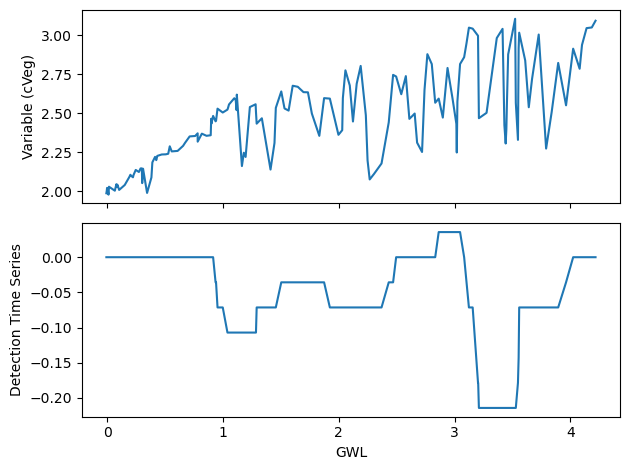

In [12]:
fig, axs = plt.subplots(2, sharex=True)
target_lon = 300.0  # e.g., 300°E
target_lat = -5.0   # e.g., 5°S

td.data[VARIABLE].sel(lon=target_lon, lat=target_lat, method="nearest").plot(ax=axs[0])
td.data[f"{VARIABLE}_dts"].sel(lon=target_lon, lat=target_lat, method="nearest").plot(ax=axs[1])

axs[0].set_ylabel(f"Variable ({VARIABLE})")
axs[1].set_ylabel("Detection Time Series")
axs[0].set_title("")
axs[1].set_title("")
axs[0].set_xlabel("")
fig.tight_layout()

### Clustering

In [13]:
### Including DBSCAN
import numpy as np
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.cluster import DBSCAN


class SpaceTimeDBSCAN(ClusterMixin, BaseEstimator):
    """DBSCAN with separate eps for spatial and temporal dimensions.

    Args:
        spatial_eps (float, optional): Epsilon for spatial dimensions in km, if using lat/lon data, else in units of the spatial dimensions
        temporal_eps (float, optional): Epsilon for the temporal dimension in units of the time variable
        min_samples (int): Minimum number of samples in a neighborhood for a point to be
            considered a core point (DBSCAN min_samples).
    """

    skip_time_scaling = True  # Protocol: TOAD skips its time scaling when True

    def __init__(
        self,
        spatial_eps,
        temporal_eps,
        min_samples=5,
    ):
        self.spatial_eps = spatial_eps
        self.temporal_eps = temporal_eps
        self.min_samples = min_samples

    def fit_predict(self, X: np.ndarray, y=None, **kwargs):
        assert y is not None, "y must be provided"

        # Scale time and space independently to control their relative importance
        X_scaled = X.copy()

        # Scale spatial dimensions by spatial_eps
        X_scaled[:, 1:] = X[:, 1:] / self.spatial_eps

        # Scale temporal dimension by temporal_eps
        X_scaled[:, 0] = X[:, 0] / self.temporal_eps

        # Now run DBSCAN with eps=1 (since we pre-scaled)
        dbscan = DBSCAN(eps=1.0, min_samples=self.min_samples, metric="euclidean")
        labels = dbscan.fit_predict(X_scaled)

        return labels

In [50]:
td.data = td.data.drop_vars(td.cluster_vars)

#DBSCAN
td.compute_clusters(
    method=SpaceTimeDBSCAN(
        spatial_eps=2000,  # km - ~800km
        temporal_eps=4.5/150*150,  # units of the time variable -> our time steps is 'GWL" ~1 degree 
        min_samples=15 # 15~55
    ),
    shift_direction='negative' # This filter only "decreasing" abrupt shift.
)

# from sklearn.cluster import HDBSCAN
# #HDBSCAN
# td.compute_clusters(
#     var="cVeg",  # reference your base variable, TOAD will find computed shifts for this variable
#     method=HDBSCAN(min_cluster_size=3),
#     time_weight=1.0,#If we use DBSCAN it won't be used
#     shift_direction='negative'
# )

INFO: New cluster variable cVeg_dts_cluster: Identified 1 cluster in 132 pts; Left 0.0% as noise (0 pts).


**DBSCAN parameter**
- **spatial_eps**: (km) How far can you tell it is the similar abrupt shift pattern? 
if one grid where away from 500km, have abrupt shift in the same time with another grid, Can you tell it would be in the same cluster?
our grid resolution is 250km, so if we set this 500km, it covers 2 grid length together.

- **temporal_eps** : (time_unit you set) We seeing vegetation carbon data per each Global warming level - and we have the annual vegetation carbon data, so our unit of time is "GWL(time)/year" 
Which time step can you tell it is close? at different grids, it show abrupt shifts after 1 year, one showed to the another. Can we say that it should be in the same cluster?



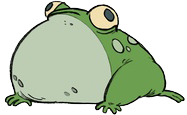

In [51]:
td

In [52]:
# You can find all method parameters used for the computation in the attributes, e.g:
getattr(td.data, f"{VARIABLE}_dts").attrs

{'long_name': 'Carbon Mass in Vegetation',
 'units': 'kg m-2',
 'cell_methods': 'area: mean where land time: mean',
 'ocean_fillvalue': np.float32(0.0),
 'cell_measures': 'area: areacella',
 'standard_name': 'vegetation_carbon_content',
 'interp_method': 'conserve_order1',
 'original_name': 'cVeg',
 'comment': 'land_area = areacella * sftlf * 0.01',
 'time_dim': 'GWL',
 'method_name': 'ASDETECT',
 'toad_version': '1.0.7',
 'base_variable': 'cVeg',
 'variable_type': 'shift',
 'shifts_ignore_nan_warnings': 'False',
 'shifts_lmin': '5',
 'shifts_segmentation': 'two_sided',
 'shifts_timescale': '(0.05, 0.1)'}

#### Let's **plot** the result:

TOAD supplies three plotting functions:

- `td.plot.overview()`

- `td.plot.cluster_map()`

- `td.plot.timeseries()`


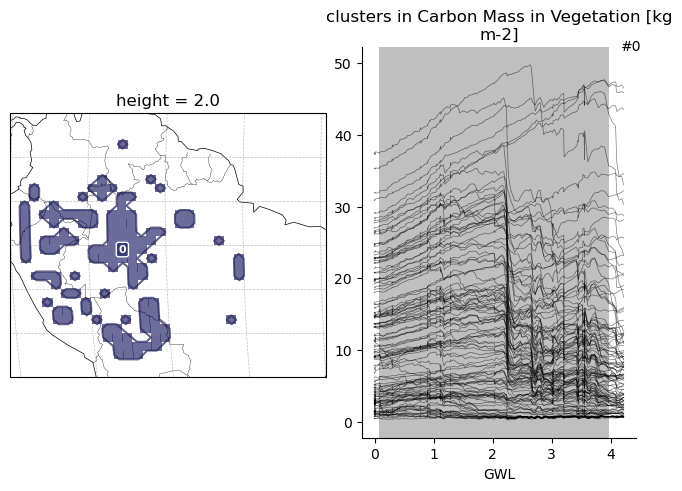

In [53]:
td.plot.overview(map_style={"projection": "global"});

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Maximum shift magnitude for cVeg'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

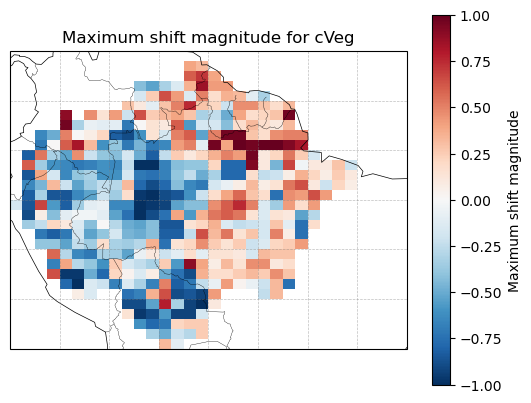

Exception ignored in: <function ResourceTracker.__del__ at 0x104d31bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104b6dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106881bc0>
Traceback (most recent call last

In [ ]:
td.plot.max_shift_map()

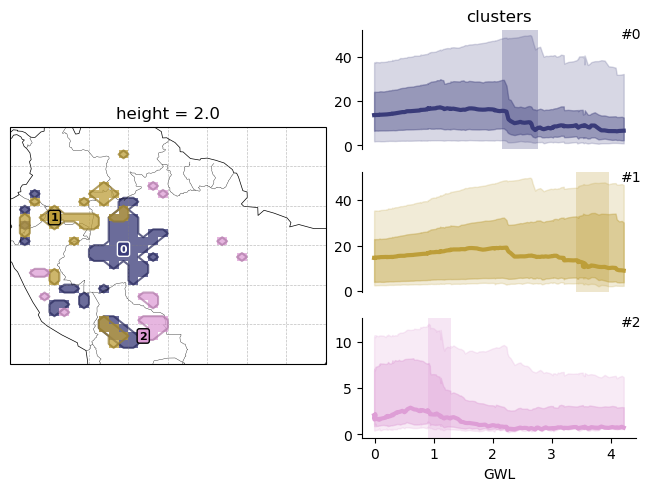

In [45]:
td.plot.overview(mode="aggregated");

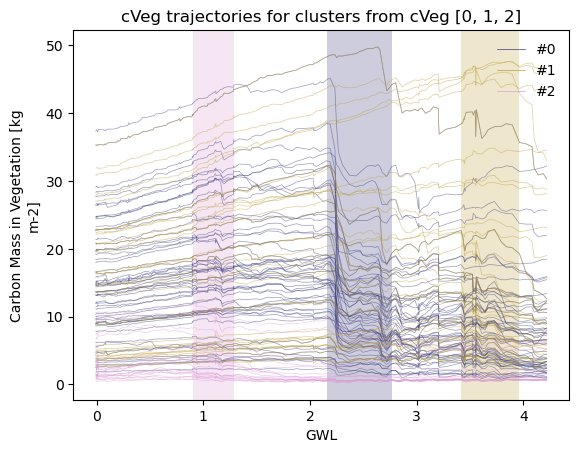

In [46]:
td.plot.timeseries(cluster_ids=[0, 1, 2, 3, 4]);

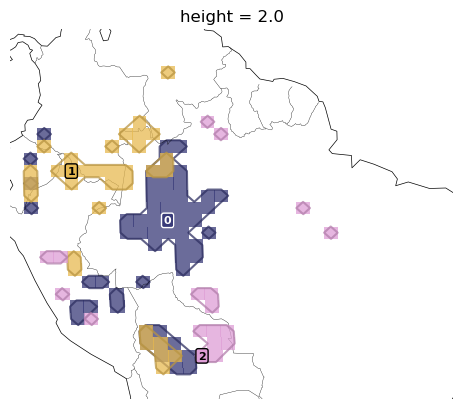

In [47]:
from toad import MapStyle

fig, ax = td.plot.cluster_map(
    cluster_ids=[0,1,2,3,4],
    include_all_clusters=False,
    map_style=MapStyle(projection="global", grid_lines=False),
)
ax.set_axis_off()

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Time of maximum shift for cVeg'}, xlabel='lon', ylabel='lat'>)

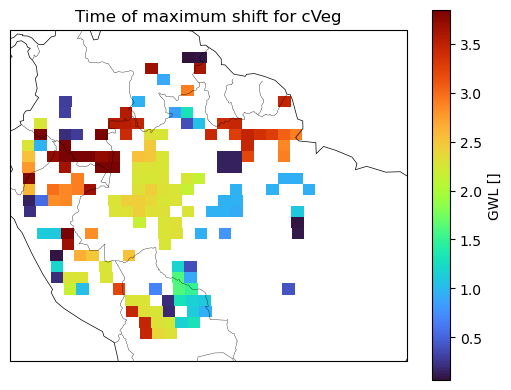

In [48]:
td.plot.time_of_max_shift_map(
    VARIABLE, map_style=MapStyle(projection="global", grid_lines=False)
)

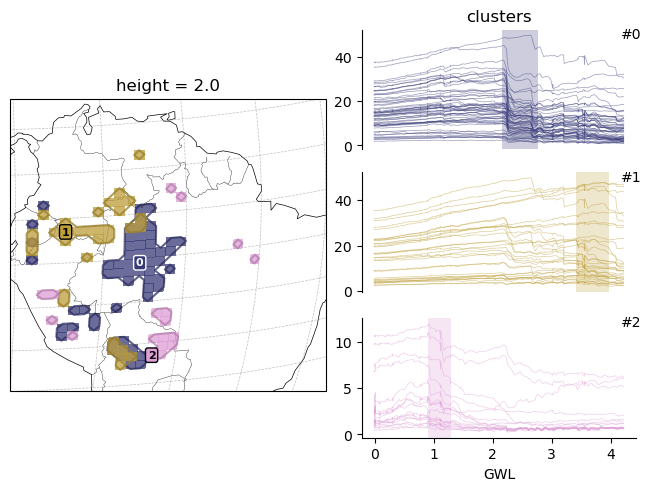

In [49]:
import cartopy.crs as ccrs

# Plot clusters
td.plot.overview(VARIABLE, map_style={"projection": ccrs.Orthographic(-90, 10)});

# Tip: map style can also be set as a dict, instead of importing the MapStyle class